In [1]:
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt

C:\Programs\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, optimizers
from tensorflow.keras.layers import Dense, InputLayer, BatchNormalization, Activation, Dropout, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
input_mat = scipy.io.loadmat('tensile-disNodes/inputData-20-frame-0.mat')
inputs_df = pd.DataFrame(input_mat['inputDataNew'])

output_mat = scipy.io.loadmat('tensile-disNodes/outputStressStrain-20-1-1500.mat')
outputs_df = pd.DataFrame(output_mat['stressStrain'])

In [5]:
outputs_df

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
0,-0.000652,0.063397,0.128222,0.193226,0.256197,0.321922,0.385225,0.450497,0.514270,0.578124,...,-0.015246,0.099028,0.034743,0.048882,0.024213,0.000262,-0.028067,0.015970,0.023800,0.028350
1,-0.000675,0.064875,0.129293,0.193646,0.258725,0.323142,0.386934,0.452786,0.517471,0.582718,...,0.154752,0.127219,0.056445,0.099227,0.026547,0.137094,0.032712,0.117956,0.012691,0.099229
2,-0.000654,0.065008,0.129141,0.194009,0.256758,0.320956,0.387813,0.453767,0.518151,0.583288,...,0.157016,0.152745,0.113344,0.141798,0.084645,0.110801,0.133353,0.112503,0.151800,0.098716
3,-0.000645,0.064322,0.129176,0.194843,0.259090,0.322289,0.386958,0.452417,0.517258,0.581012,...,0.091887,0.213941,0.028424,0.199534,0.084275,0.074304,0.143926,0.042894,0.233217,0.055415
4,-0.000675,0.064310,0.130469,0.195103,0.261453,0.326040,0.390748,0.455793,0.519762,0.583734,...,0.180627,-0.016959,0.071345,0.020978,-0.014815,0.067421,0.119922,-0.050136,0.011482,0.053425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,-0.000678,0.065252,0.129835,0.193666,0.257103,0.322642,0.386729,0.451533,0.517565,0.581311,...,0.111116,-0.027878,-0.059865,0.034550,0.028826,0.123454,-0.117628,0.117106,0.107739,0.013842
1496,-0.000661,0.064010,0.130410,0.194166,0.257890,0.322961,0.388432,0.451114,0.516335,0.581273,...,0.072573,0.105946,0.162136,0.099505,0.109957,0.141952,0.114935,0.123268,0.067128,0.087515
1497,-0.000667,0.064389,0.129306,0.195552,0.260618,0.324494,0.389436,0.454238,0.519166,0.583380,...,0.079386,0.148011,0.278471,0.097104,-0.011394,0.156593,0.254713,0.165437,0.105459,0.181121
1498,-0.000648,0.063983,0.130115,0.194989,0.258499,0.321541,0.385247,0.449552,0.514216,0.578445,...,0.173914,0.373275,0.041926,0.255004,0.120657,0.249371,0.167717,0.130959,0.179999,0.072233


In [6]:
inputs = []
for index, row in inputs_df.iterrows():
    row = list(row)
    inputs.append([row])
inputs = np.array(inputs)
    
outputs = []
for index, row in outputs_df.iterrows():
    row = list([row])
    outputs.append(row)
outputs = np.array(outputs)

In [7]:
def build_model(inputs, outputs, verbose=0):
    model = Sequential(name='FCNN')

    model.add(InputLayer(input_shape=(1, len(inputs[0][0]))))
    model.add(BatchNormalization())

    model.add(Dense(2048))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(LSTM(1024, input_shape=[2048], return_sequences=True))
    model.add(Dense(1024))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Dense(1024))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(LSTM(512, input_shape=[1024], return_sequences=True))
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Dense(len(outputs[0])))
    
    OPT = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    METS = ['ACC', 'MAE', 'MSE']
    model.compile(optimizer=OPT, loss='MSE', metrics=METS)  # , loss_weights=[1,2])

    if verbose == 1:
        print(model.summary())
    
    return model


def train_model(model, train_in, train_out, EPOCHS=100, BATCH=16, callbacks=None, verbose=0):
    early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=verbose, mode='min')
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=5, verbose=verbose,
                                  min_delta=1e-4, mode='min')
    if callbacks:
        callbacks = [reduce_lr , early_stop]

    fitHistory = model.fit(train_in, train_out, epochs=EPOCHS, batch_size=BATCH, validation_split=0.1, verbose=verbose, 
                           callbacks=callbacks)  #, sample_weight=self.weights)

    fitHistory_df = pd.DataFrame(fitHistory.history)

    return fitHistory, fitHistory_df

In [8]:
model = build_model(inputs=inputs, 
                    outputs=outputs,
                    verbose=1)

fitHistory, fitHistory_df = train_model(model=model, 
                                        train_in=inputs, 
                                        train_out=outputs, 
                                        EPOCHS=10, 
                                        BATCH=50, 
                                        callbacks=True,
                                        verbose=1)


Model: "FCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (Batch  (None, 1, 826)            3304      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 1, 2048)           1693696   
                                                                 
 batch_normalization_1 (Bat  (None, 1, 2048)           8192      
 chNormalization)                                                
                                                                 
 activation (Activation)     (None, 1, 2048)           0         
                                                                 
 lstm (LSTM)                 (None, 1, 1024)           12587008  
                                                                 
 dense_1 (Dense)             (None, 1, 1024)           104960

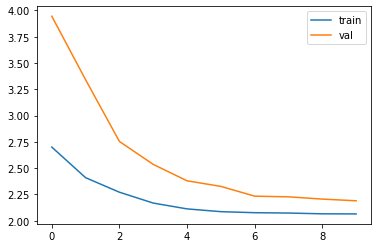

In [9]:
plt.plot(list(fitHistory.history.values())[0], label='train')
plt.plot(list(fitHistory.history.values())[4], label='val')
plt.legend()